In [109]:
#23/9/2026

In [110]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_predict,StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

import warnings
warnings.filterwarnings("ignore")
df=pd.read_csv("diabetes.csv")

In [111]:
df = pd.read_csv("diabetes.csv")

print(df.head(8))


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   
5            5      116             74              0        0  25.6   
6            3       78             50             32       88  31.0   
7           10      115              0              0        0  35.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
5                     0.201   30        0  
6                     0.248   26        1  

In [112]:
print(df.tail(15))

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
753            0      181             88             44      510  43.3   
754            8      154             78             32        0  32.4   
755            1      128             88             39      110  36.5   
756            7      137             90             41        0  32.0   
757            0      123             72              0        0  36.3   
758            1      106             76              0        0  37.5   
759            6      190             92              0        0  35.5   
760            2       88             58             26       16  28.4   
761            9      170             74             31        0  44.0   
762            9       89             62              0        0  22.5   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             

In [113]:
print(df.shape)


(768, 9)


In [114]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [115]:
df.drop_duplicates()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [116]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [117]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [118]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [119]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


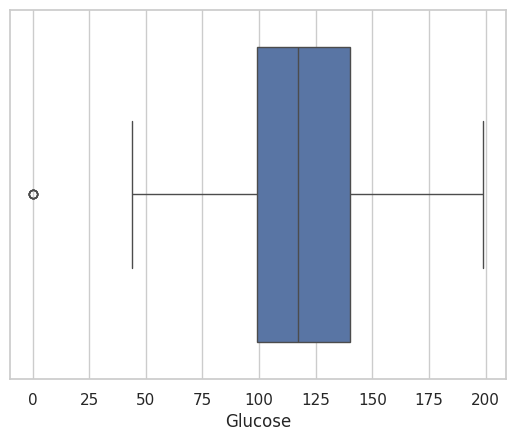

In [120]:
sns.boxplot(x = df["Glucose"])
plt.show()

In [121]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[zero_columns]==0).sum()

print(zero_counts)

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [122]:
df_clean = df.copy()
df_clean[zero_columns] = df_clean[zero_columns].replace(0,np.nan)
print("Missing values after replacing invalid zeroes")
print(df_clean.isnull().sum())

Missing values after replacing invalid zeroes
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [123]:
for col in zero_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Missing values after meadian missing values")
print(df_clean.isnull().sum())

Missing values after meadian missing values
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


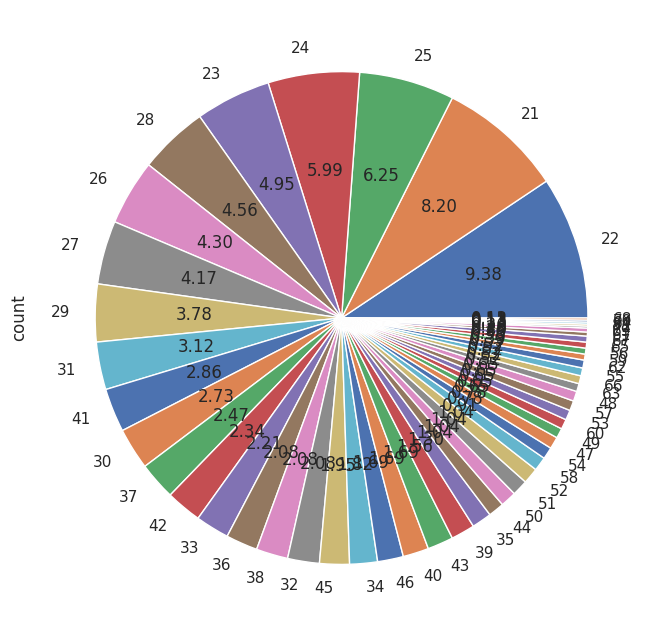

In [124]:
plt.figure(figsize = (14,8))
df['Age'].value_counts().plot(kind = "pie", autopct = "%.2f")
plt.show()

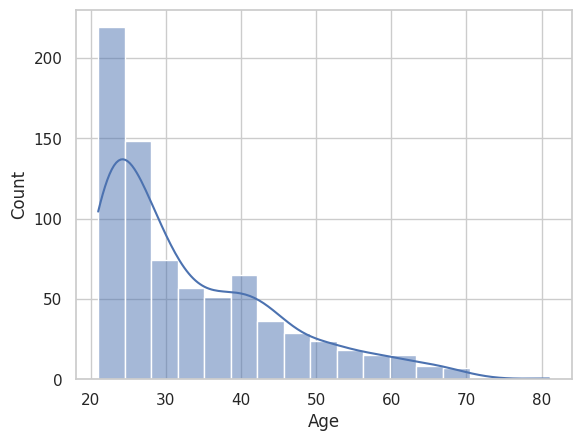

In [125]:
sns.histplot(df["Age"], kde = True)
plt.show()

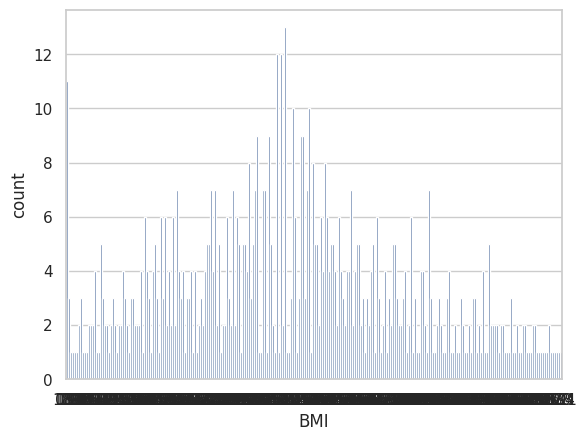

In [126]:
sns.countplot(x = "BMI", data = df)      # Only for output
plt.show()

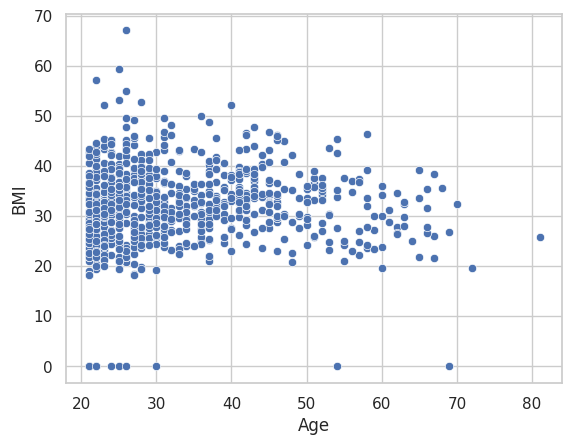

In [127]:
sns.scatterplot(x = "Age", y = "BMI", data = df)
plt.show()

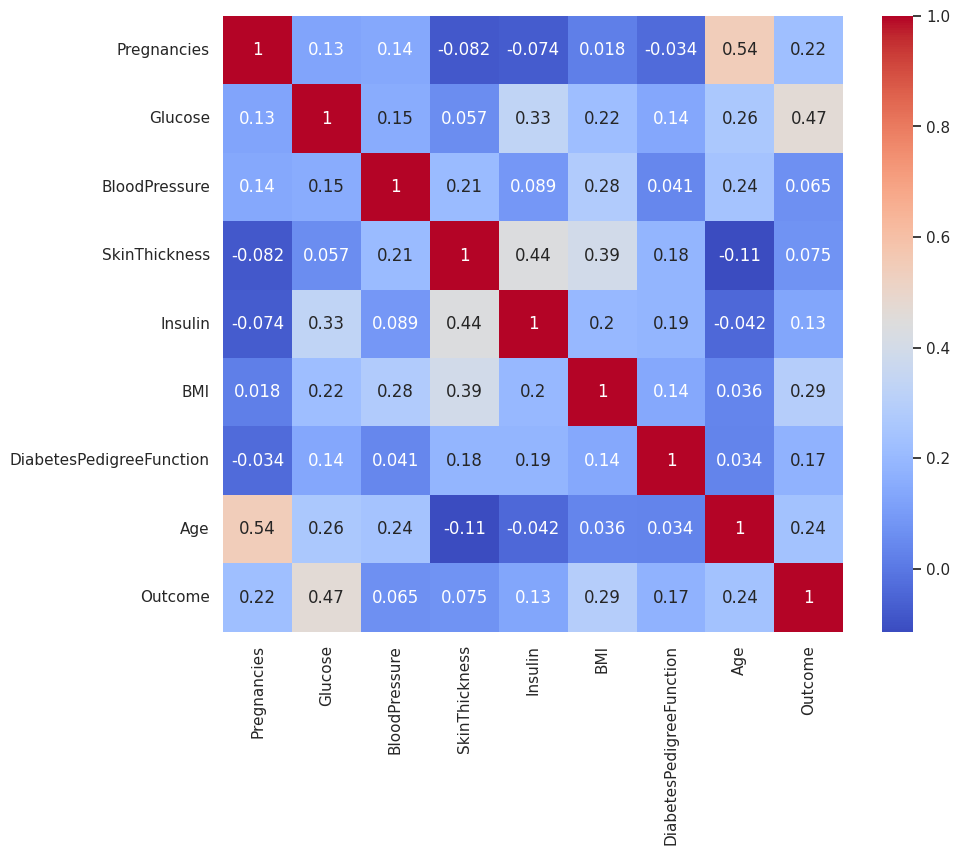

In [128]:
plt.figure(figsize = (10,8))

numeric_df = df.select_dtypes(include = ['number'])

sns.heatmap(numeric_df.corr(), annot = True, cmap = "coolwarm")
plt.show()

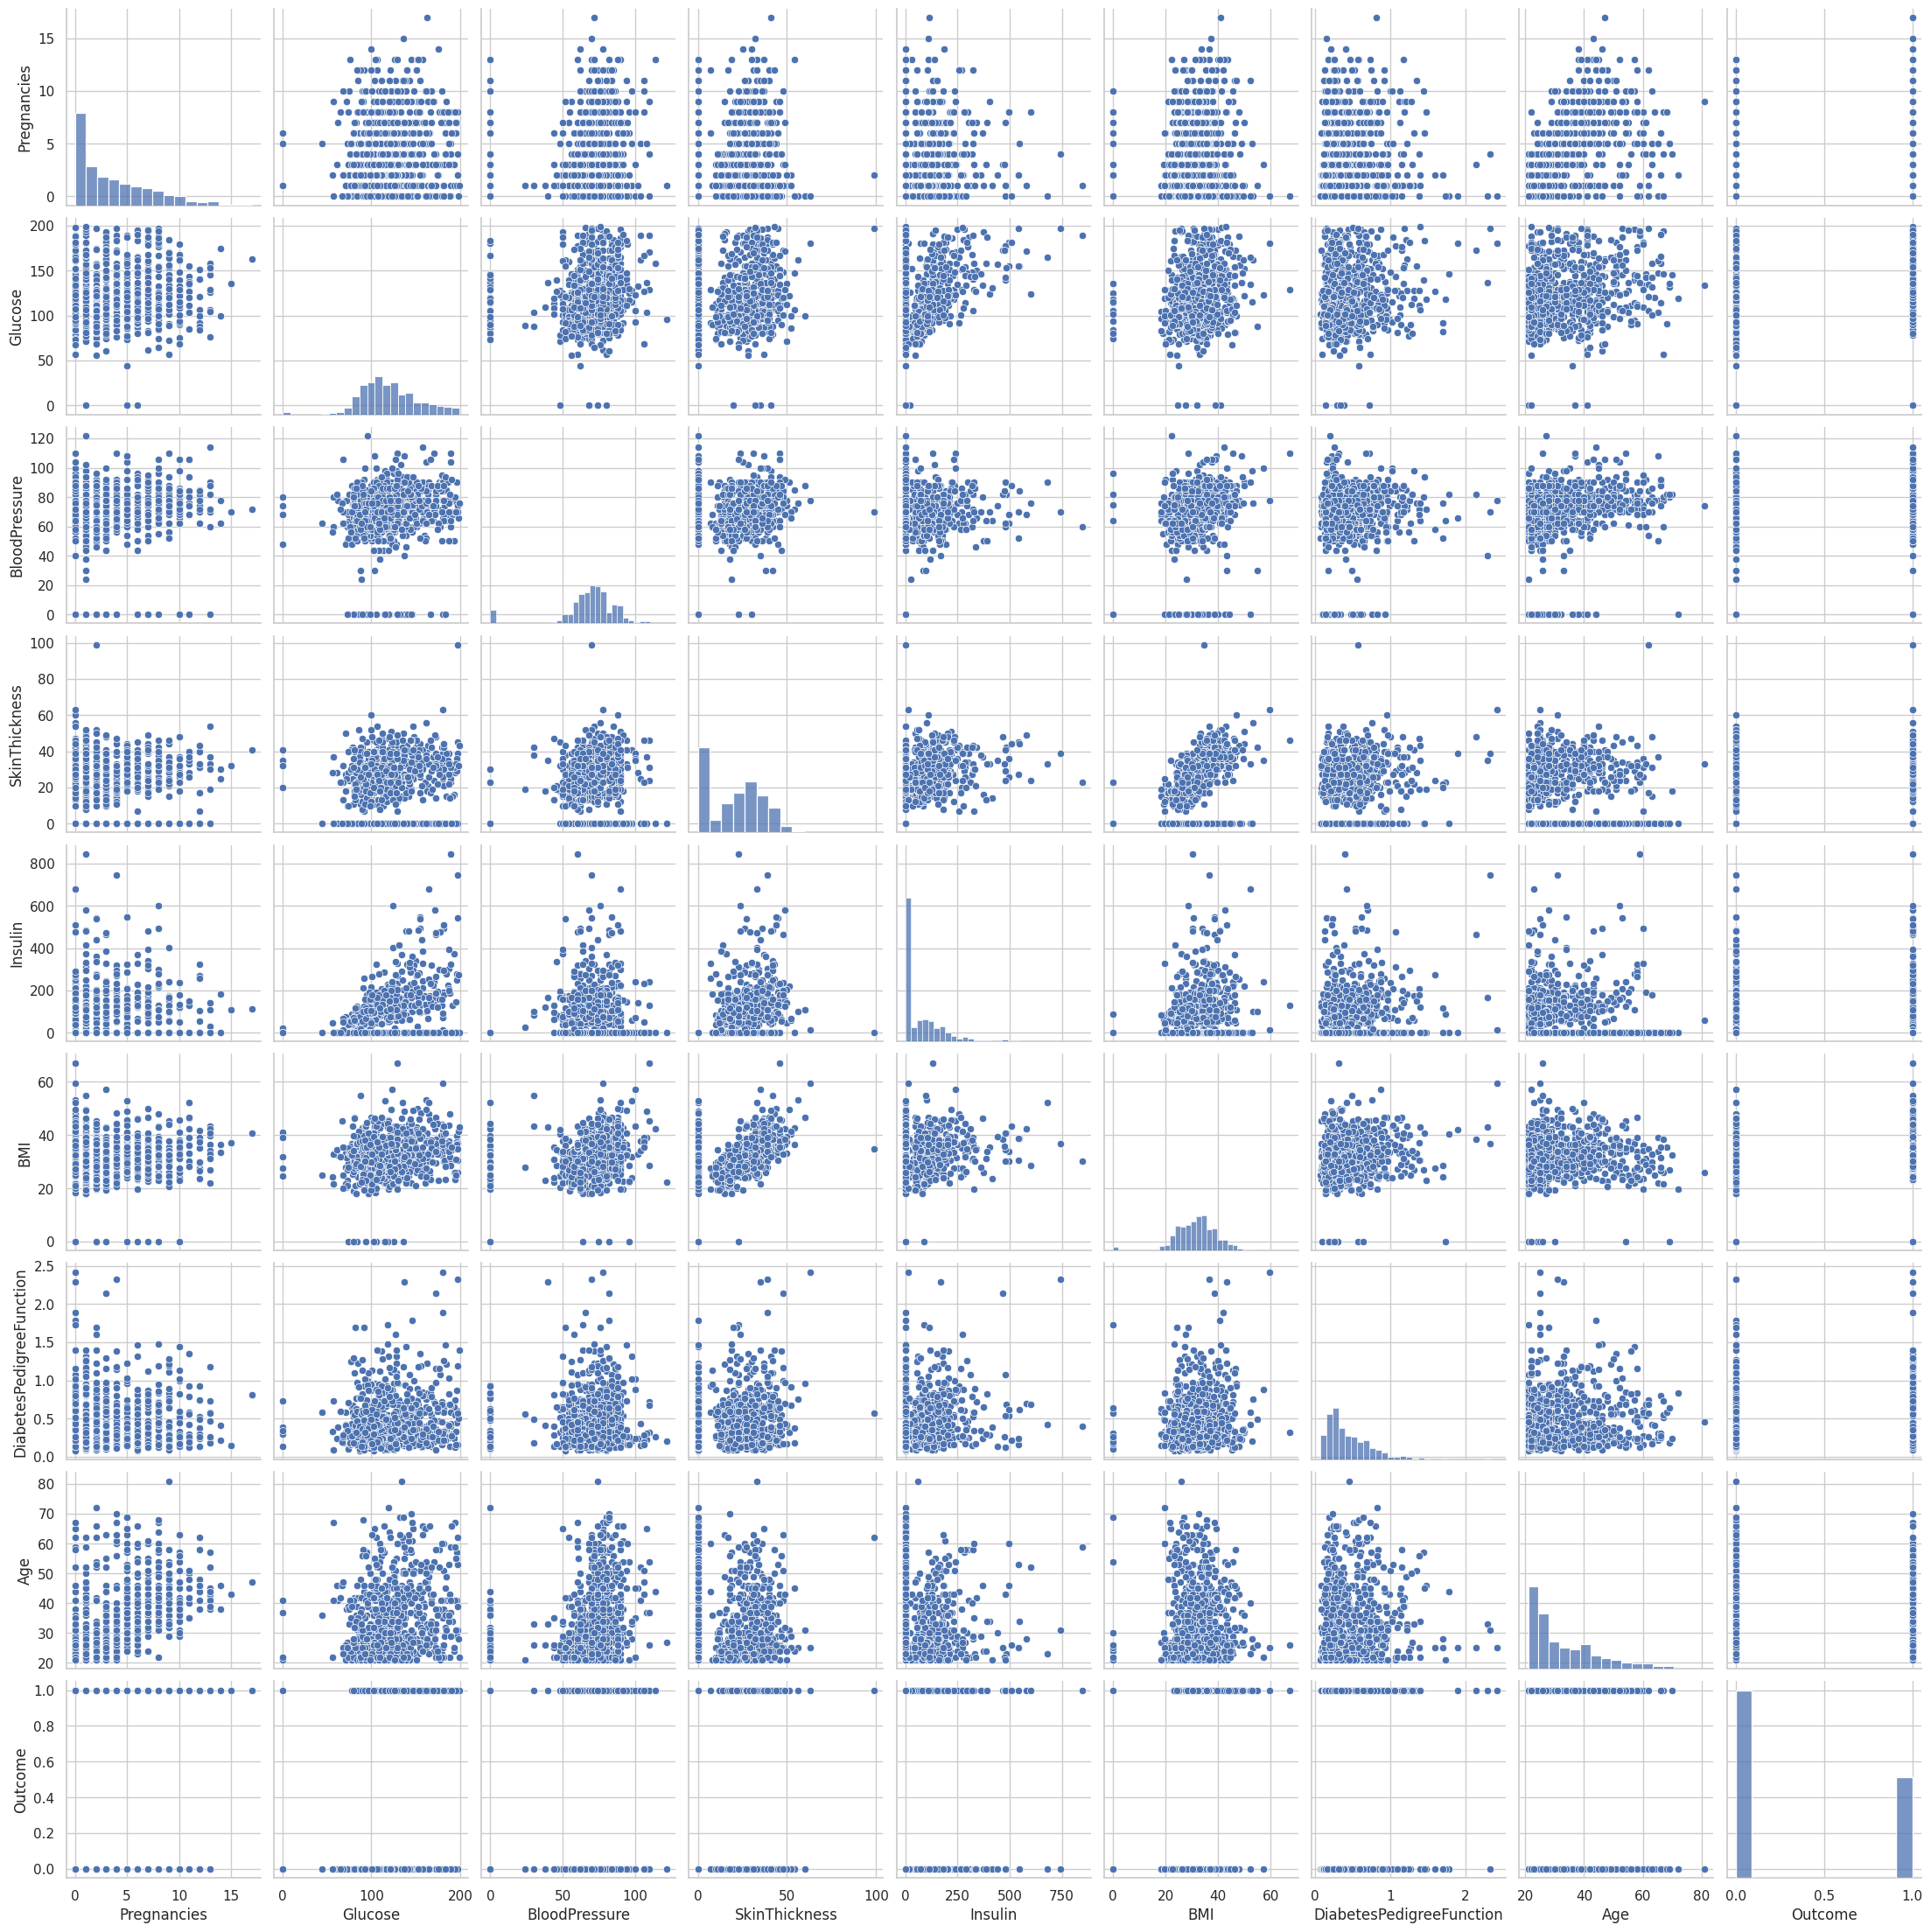

In [129]:
sns.pairplot(df)
plt.show()

In [130]:
# Here the basic EDA techniques end and Traing and KNN STARTS

# Steps:
# 1. x,y,split
# 2. standard scaler
# 3. k = 5
# 4. accuracy, precision , recall, f1 score
# 5. CM
# 6. Hyperparameter Tuning

In [131]:
X= df_clean.drop("Outcome", axis = 1)
y = df_clean["Outcome"]

print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (768, 8)
Shape of y:  (768,)


In [132]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [133]:
print("Training Distribution:")
print(y_train.value_counts(normalize = True))

print("\nTesting Distribution:")
print(y_test.value_counts(normalize = True))

Training Distribution:
Outcome
0    0.653094
1    0.346906
Name: proportion, dtype: float64

Testing Distribution:
Outcome
0    0.642857
1    0.357143
Name: proportion, dtype: float64


In [134]:
#Standard Scaler - sd = 1 , mean = 0
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [135]:
scaler.fit_transform(X_test)

array([[ 0.49124165, -0.72667791, -1.2442565 , ...,  0.17113929,
        -0.17094071,  0.66661154],
       [-0.63368347, -0.28534901,  0.16468101, ...,  0.42819187,
        -1.08608042, -1.07335756],
       [-0.63368347, -0.41144298, -0.74698444, ..., -0.3127244 ,
        -1.05362866, -1.07335756],
       ...,
       [ 1.05370422, -0.82124838, -0.08395502, ...,  0.59452001,
         0.00754398,  1.77386461],
       [-0.63368347,  0.78644972, -0.24971238, ..., -0.73610513,
        -0.47274211, -0.44064153],
       [ 1.05370422, -1.48324172, -0.24971238, ...,  0.36770891,
         0.72148276,  0.35025352]])

In [136]:
scaler.transform(X_test)

array([[ 0.49124165, -0.72667791, -1.2442565 , ...,  0.17113929,
        -0.17094071,  0.66661154],
       [-0.63368347, -0.28534901,  0.16468101, ...,  0.42819187,
        -1.08608042, -1.07335756],
       [-0.63368347, -0.41144298, -0.74698444, ..., -0.3127244 ,
        -1.05362866, -1.07335756],
       ...,
       [ 1.05370422, -0.82124838, -0.08395502, ...,  0.59452001,
         0.00754398,  1.77386461],
       [-0.63368347,  0.78644972, -0.24971238, ..., -0.73610513,
        -0.47274211, -0.44064153],
       [ 1.05370422, -1.48324172, -0.24971238, ...,  0.36770891,
         0.72148276,  0.35025352]])

In [137]:
comparison = pd.DataFrame({"Before Scaling": X_test.iloc[0], "After Scaling": X_test_scaled[0],
                           "Original Mean": X_train.mean(axis=0),
                           "Original SD": X_train.std(axis=0),
                           "Scaled Mean": X_train_scaled.mean(axis=0),
                           "Scaled SD": X_train_scaled.std(axis=0)})
display(comparison)


,Before Scaling,After Scaling,Original Mean,Original SD,Scaled Mean,Scaled SD
Pregnancies,6.00,0.681856,3.742671,3.313264,1.735854e-17,1.0
Glucose,98.00,-0.791466,121.807818,30.105181,9.836504e-17,1.0
BloodPressure,58.00,-1.177033,72.229642,12.099278,-1.157236e-17,1.0
SkinThickness,33.00,0.510202,28.711726,8.411906,1.417614e-16,1.0
Insulin,190.00,0.561935,140.477199,88.200972,-1.432079e-16,1.0
BMI,34.00,0.237865,32.351629,6.935519,-3.703154e-16,1.0
DiabetesPedigreeFunction,0.43,-0.116372,0.469168,0.336847,1.562268e-16,1.0
Age,43.00,0.878091,32.907166,11.503437,-3.761016e-17,1.0


In [138]:
# Here penalty factor will be K
K= 5

In [139]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [140]:
y_pred = knn.predict(X_test_scaled)
print("Prediction")
print(y_pred[:20])

Prediction
[1 0 0 1 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1 1]


In [141]:
y_prob = knn.predict_proba(X_test_scaled)
print("Probability")
print(y_prob[:20])

Probability
[[0.2 0.8]
 [0.6 0.4]
 [1.  0. ]
 [0.4 0.6]
 [0.2 0.8]
 [0.4 0.6]
 [1.  0. ]
 [0.6 0.4]
 [0.4 0.6]
 [0.8 0.2]
 [0.6 0.4]
 [0.2 0.8]
 [0.8 0.2]
 [0.6 0.4]
 [1.  0. ]
 [0.6 0.4]
 [1.  0. ]
 [1.  0. ]
 [0.  1. ]
 [0.4 0.6]]


In [142]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

In [143]:
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7208
Precision: 0.5968
Recall: 0.6727
F1 Score: 0.6325


In [144]:
print(classification_report(y_test, y_pred, target_names = ["No Diabetes", "Diabetes"]))

              precision    recall  f1-score   support

 No Diabetes       0.80      0.75      0.77        99
    Diabetes       0.60      0.67      0.63        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154



In [145]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[74 25]
 [18 37]]


Text(66.25, 0.5, 'True Labels')

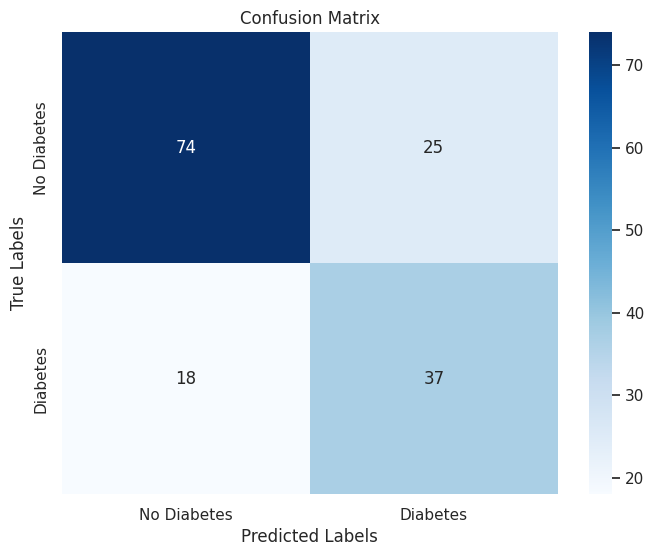

In [146]:
plt.figure(figsize = (8,6))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues",xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

In [147]:
k_values = range(1,31)

train_accuracy =[]
test_accuuracy = []
for k in k_values:
  model = KNeighborsClassifier(n_neighbors = k)
  model.fit(X_train_scaled, y_train)
  train_accuracy.append(model.score(X_train_scaled, y_train))
  test_accuuracy.append(model.score(X_test_scaled, y_test))

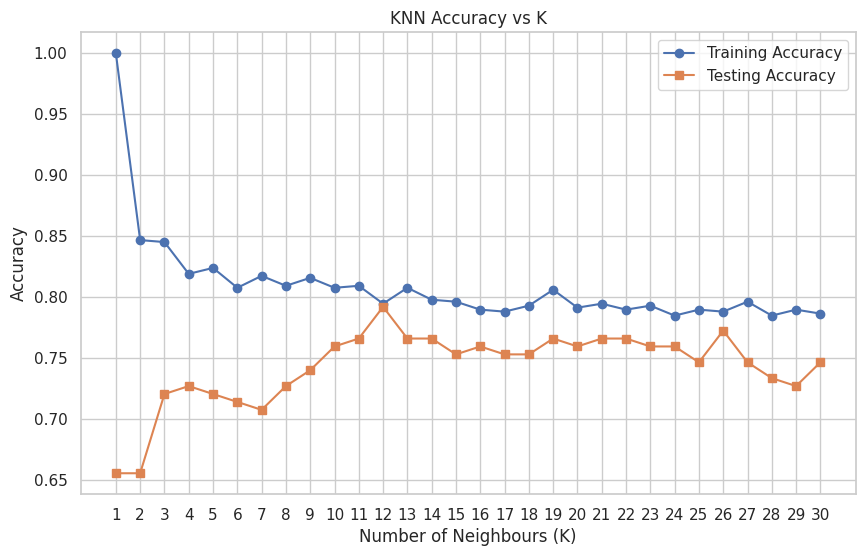

In [148]:
plt.figure(figsize = (10,6))
plt.plot(k_values, train_accuracy,marker = "o", label = "Training Accuracy")
plt.plot(k_values, test_accuuracy,marker = "s", label = "Testing Accuracy")

plt.xlabel("Number of Neighbours (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.xticks(k_values)
plt.legend()
plt.show()

In [149]:
best_k_accuracy = k_values[np.argmax(test_accuuracy)]
best_accuracy = max(test_accuuracy)
print("Best Accuracy:", best_accuracy)
print("Best K value:", best_k_accuracy)

Best Accuracy: 0.7922077922077922
Best K value: 12


In [150]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
cv_scores = []

for k in range(1,31):
  model = KNeighborsClassifier(n_neighbors = k)
  scores = cross_val_score(model, X_train_scaled, y_train, cv = cv, scoring = "accuracy")
  cv_scores.append(scores.mean())

In [151]:
best_k_cv=np.argmax(cv_scores)+1
print("Best k based on cross Validation: ",best_k_cv)
print("Best CV accuracy:",max(cv_scores))

Best k based on cross Validation:  16
Best CV accuracy: 0.7768759163001466


In [152]:
param_grid = {
    "n_neighbors": range(1, 31,2),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2]
}

In [153]:
grid_search= GridSearchCV(estimator=KNeighborsClassifier(),param_grid=param_grid,cv=5,scoring="accuracy",n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)
print("Grid Search completed")

Grid Search completed


In [154]:
print("Best Parameters")
print(grid_search.best_params_)


Best Parameters
{'metric': 'euclidean', 'n_neighbors': 23, 'p': 1, 'weights': 'uniform'}


In [155]:
best_knn = grid_search.best_estimator_
print(best_knn)


KNeighborsClassifier(metric='euclidean', n_neighbors=23, p=1)


In [156]:
final_pred = best_knn.predict(X_test_scaled)
final_prob = best_knn.predict_proba(X_test_scaled)[:,1]
